# **Exploration and Data Preparation**

## Download and Load dataset

In [ ]:
import pandas as pd
import requests
import io
import os

# Google Drive download link
google_drive_url = 'https://drive.google.com/uc?export=download&id=187xOqm7Km5hpqSWY-JH3Lein3bYIO-Ae'
output = 'dataset.csv'

print(f"Downloading from: {google_drive_url}")

try:
    response = requests.get(google_drive_url, stream=True)
    response.raise_for_status()

    with open(output, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    print("Download complete.")

    if os.path.exists(output):
        try:
            df = pd.read_csv(output, sep=',', engine='python', on_bad_lines='skip')
            print("Dataset loaded successfully!")
            display(df.head())
        except Exception as e:
            print(f"Error loading dataset: {e}")
    else:
        print("Failed to download the dataset.")

except requests.exceptions.RequestException as e:
    print(f"Error during download: {e}")

Download complete.
Dataset loaded successfully!


,Tweet Date,Sentence,Quote Count,Reply Count,Retweet Count,Favorite Count,Sentiment,English Translation
0,Thu Feb 29 11:21:27 +0000 2024,"Gk muluk muluk, 100,000 lot saham BBCA aja",0,0,0,0,Positive,"Not too ambitious, just 100,000 lots of BBCA s..."
1,Thu Feb 29 10:11:05 +0000 2024,BCA Expoversary 2024 menawarkan promo suku bun...,0,0,0,0,Neutral,BCA Expoversary 2024 offers special interest r...
2,Thu Feb 29 10:06:04 +0000 2024,[USERNAME] saham bca nya menyusul ya 🙂,0,0,0,0,Positive,[USERNAME] BCA shares will follow 🙂
3,Thu Feb 29 07:42:09 +0000 2024,PT Bank BCA Syariah (BCA Syariah) turut memeri...,0,0,0,0,Neutral,PT Bank BCA Syariah (BCA Syariah) also enliven...
4,Thu Feb 29 06:06:17 +0000 2024,[USERNAME] Begitu byk saham kamu memilih saham...,0,0,0,1,Positive,[USERNAME] So many stocks you choose those sto...


## Data Exploration

In [ ]:
display(df.info())
display(df.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Tweet Date           3288 non-null   object
 1   Sentence             3288 non-null   object
 2   Quote Count          3288 non-null   int64 
 3   Reply Count          3288 non-null   int64 
 4   Retweet Count        3288 non-null   int64 
 5   Favorite Count       3288 non-null   int64 
 6   Sentiment            3288 non-null   object
 7   English Translation  3288 non-null   object
dtypes: int64(4), object(4)
memory usage: 205.6+ KB


None

,Tweet Date,Sentence,Quote Count,Reply Count,Retweet Count,Favorite Count,Sentiment,English Translation
count,3288,3288,3288.000000,3288.000000,3288.000000,3288.000000,3288,3288
unique,3263,3254,NaN,NaN,NaN,NaN,3,3251
top,Wed Jan 03 05:12:21 +0000 2024,[HASHTAG] PT Telkom Indonesia Tbk (TLKM) membu...,NaN,NaN,NaN,NaN,Positive,"BBNI shares closed at Rp5,375 per share or up ..."
freq,2,4,NaN,NaN,NaN,NaN,1769,5
mean,NaN,NaN,0.374696,1.113747,1.276460,7.162409,NaN,NaN
std,NaN,NaN,7.214358,8.818134,26.474467,136.684489,NaN,NaN
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,0.000000,1.000000,0.000000,1.000000,NaN,NaN


,count
Sentiment,
Positive,1769
Negative,786
Neutral,733


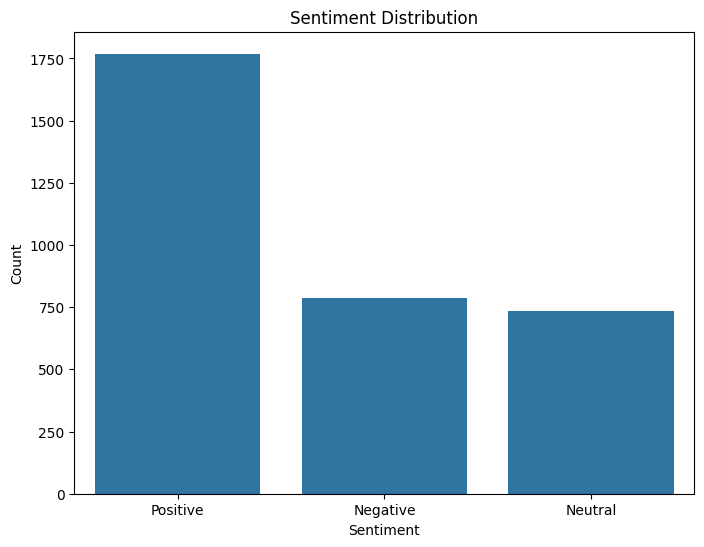

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get value counts for the 'Sentiment' column
sentiment_counts = df['Sentiment'].value_counts()

# Display the value counts
display(sentiment_counts)

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## Preprocessing

In [ ]:
# Drop unnecessary columns
df = df[['Sentence', 'Sentiment', 'English Translation']]

# Display the head of the modified DataFrame
display(df.head())

,Sentence,Sentiment,English Translation
0,"Gk muluk muluk, 100,000 lot saham BBCA aja",Positive,"Not too ambitious, just 100,000 lots of BBCA s..."
1,BCA Expoversary 2024 menawarkan promo suku bun...,Neutral,BCA Expoversary 2024 offers special interest r...
2,[USERNAME] saham bca nya menyusul ya 🙂,Positive,[USERNAME] BCA shares will follow 🙂
3,PT Bank BCA Syariah (BCA Syariah) turut memeri...,Neutral,PT Bank BCA Syariah (BCA Syariah) also enliven...
4,[USERNAME] Begitu byk saham kamu memilih saham...,Positive,[USERNAME] So many stocks you choose those sto...


In [ ]:
import pandas as pd
import re
import requests

# --- 1. Download Normalization Dictionary (Slang Dictionary) ---
slang_url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
try:
    slang_df = pd.read_csv(slang_url)
    slang_dict = dict(zip(slang_df['slang'], slang_df['formal']))
    print("Kamus normalisasi berhasil dimuat!")
except Exception as e:
    print(f"Gagal memuat kamus: {e}")
    slang_dict = {}

# --- 1.5. Creating whitelist related to stock domains ---
# This list is adjusted to the 10 Stocks in Paper ID-SMA
# We enter the Ticker AND the common name of the company to be safe.
saham_whitelist = [
    # 1. BBCA (Bank Central Asia)
    'bbca', 'bca',
    # 2. UNVR (Unilever Indonesia)
    'unvr', 'unilever',
    # 3. TPIA (Chandra Asri Petrochemical)
    'tpia', 'chandra', 'asri',
    # 4. TLKM (Telkom Indonesia)
    'tlkm', 'telkom',
    # 5. HMSP (Hanjaya Mandala Sampoerna)
    'hmsp', 'sampoerna',
    # 6. BYAN (Bayan Resources)
    'byan', 'bayan',
    # 7. BMRI (Bank Mandiri)
    'bmri', 'mandiri',
    # 8. BBRI (Bank Rakyat Indonesia)
    'bbri', 'bri',
    # 9. BBNI (Bank Negara Indonesia)
    'bbni', 'bni',
    # 10. ASII (Astra International)
    'asii', 'astra',

    # --- Important Additions Whitelist Based on the ID-SMSA Dataset ---

    # 1. Other Frequently Appearing Stock Codes (Peers/Competitors)
    'goto', 'buka', 'bukalapak',       # Technology Sector (often compared with digital banks/telcos)
    'admr', 'adro', 'adaro',           # Energy Sector (often compared with BYAN)
    'itmg', 'ptba', 'bumi',            # Energy Sector (Peers)
    'antm', 'antam', 'inco', 'mdka',   # Metal Mining Sector (Peers)
    'icbp', 'indf', 'myor', 'sido',    # Consumen Sector (Peers UNVR/HMSP)
    'ggrm', 'wiim',                    # Tobacco Sector (Peers HMSP)
    'btps', 'bris', 'agro', 'arto',    # Digital/Sharia Banks (Peers Big Banks)
    'pgas', 'pegas',                   # Energy/Infrastructure
    'bren', 'cuan', 'brpt',            # Barito Group (often mentioned along with TPIA)

    # 2. Capital Market Terms (Slang/Acronyms)
    'lot',          # Unit of shares (don't normalize to 'lho' or others)
    'cuan',         # Profit (don't normalize to another word)
    'boncos',       # Loss
    'serok',        # Buy at the bottom (or Scoop)
    'nyangkut',     # Floating Loss (or Stuck/Holding at a loss)
    'cl',           # Cut Loss
    'tp',           # Take Profit
    'haka',         # Hajar Kanan (Direct Buy / Hit Right)
    'haki',         # Hajar Kiri (Direct Sell / Hit Left)
    'ara',          # Auto Reject Atas (Upper Auto Rejection)
    'arb',          # Auto Reject Bawah (Lower Auto Rejection)
    'ath',          # All Time High
    'ytd',          # Year to Date
    'pbv', 'per',   # Financial Ratios
    'ihsg',         # Composite Stock Price Index
    'lq45',         # Stock Index
    'idx',          # Stock Exchange
    'sekuritas',    # Brokerage Firm (or Securities)
    'dividen',      # Brokerage Firm (or Securities)
    'stockbit',     # Application (often mentioned)
    'bibit',        # Application
    'ajaib',        # Application
    'ipot'          # Application


]

print(f"Menghapus {len(saham_whitelist)} kata kunci saham dari kamus slang...")
for word in saham_whitelist:
    if word in slang_dict:
        del slang_dict[word]

# --- 2. Complete Preprocessing Function ---
def preprocess_text_complete(text):
    # A. Case Folding
    text = text.lower()

    # B. Text Cleaning (Regex)
    text = re.sub(r'\[username\]|\[url\]|\[hashtag\]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\d+', '', text)

    # C. Normalization (Slang replacement)
    words = text.split()
    # Replace slang words with standard words if they exist in the dictionary, EXCEPT for the whitelist
    normalized_words = [slang_dict.get(word, word) for word in words]
    text = ' '.join(normalized_words)

    # D. Whitespace Removal
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# --- 3. Apply to DataFrame ---
print("Sedang melakukan preprocessing (Cleaning + Normalization dengan Whitelist Lengkap)...")
df['cleaned_sentence'] = df['Sentence'].apply(preprocess_text_complete)
# Apply basic cleaning for English text (without slang normalization)
df['cleaned_english'] = df['English Translation'].apply(lambda x: re.sub(r'\s+', ' ', re.sub(r'[^a-zA-Z0-9\s]', ' ', re.sub(r'http\S+|www\S+|\[.*?\]', '', x.lower()))).strip())

print("Preprocessing Selesai.")

# Perform a random sample check to ensure
print("\nCek sampel data:")
display(df[['Sentence', 'cleaned_sentence']].sample(5))

Kamus normalisasi berhasil dimuat!
Menghapus 73 kata kunci saham dari kamus slang...
Sedang melakukan preprocessing (Cleaning + Normalization dengan Whitelist Lengkap)...
Preprocessing Selesai.

Cek sampel data:


,Sentence,cleaned_sentence
1651,Awas 'Kebakaran'! Saham UNVR-GGRM-HMSP cs Diob...,awas kebakaran saham unvr ggrm hmsp cs diobral...
2111,IHSG naik +80 poin di 6.916 Santa rally di akh...,ihsg naik poin di santa rally di akhir tahun t...
2442,Bbri atau bmri,bbri atau bmri
3266,"IHSG Diprediksi Sideways, Cek Rekomendasi Saha...",ihsg diprediksi sideways cek rekomendasi saham...
2955,Harga saham PT Bank Negara Indonesia (Persero)...,harga saham pt bank negara indonesia persero t...


## Label Encoding

In [ ]:
# Show sentiment distribution before encoding
print("Distribusi Sentimen Sebelum Encoding:")
print(df['Sentiment'].value_counts())
print("-" * 30)

# 1. Create a dictionary to map sentiments to numbers
sentiment_map = {
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
}

# 2. Apply the mapping to create a new 'label' column
df['label'] = df['Sentiment'].map(sentiment_map)

# 3. Display the result to ensure everything is correct
# Note the new 'label' column on the far right
print("DataFrame Setelah Label Encoding:")
display(df.head())

# 4. Re-check the distribution in the new 'label' column to ensure no data is lost
print("\nDistribusi di Kolom 'label' Baru:")
print(df['label'].value_counts())

Distribusi Sentimen Sebelum Encoding:
Sentiment
Positive    1769
Negative     786
Neutral      733
Name: count, dtype: int64
------------------------------
DataFrame Setelah Label Encoding:


,Sentence,Sentiment,English Translation,cleaned_sentence,cleaned_english,label
0,"Gk muluk muluk, 100,000 lot saham BBCA aja",Positive,"Not too ambitious, just 100,000 lots of BBCA s...",enggak muluk muluk lot saham bbca saja,not too ambitious just 100 000 lots of bbca sh...,2
1,BCA Expoversary 2024 menawarkan promo suku bun...,Neutral,BCA Expoversary 2024 offers special interest r...,bca expoversary menawarkan promo suku bunga sp...,bca expoversary 2024 offers special interest r...,1
2,[USERNAME] saham bca nya menyusul ya 🙂,Positive,[USERNAME] BCA shares will follow 🙂,saham bca nya menyusul ya,bca shares will follow,2
3,PT Bank BCA Syariah (BCA Syariah) turut memeri...,Neutral,PT Bank BCA Syariah (BCA Syariah) also enliven...,pt bank bca syariah bca syariah turut memeriah...,pt bank bca syariah bca syariah also enlivened...,1
4,[USERNAME] Begitu byk saham kamu memilih saham...,Positive,[USERNAME] So many stocks you choose those sto...,begitu banyak saham kamu memilih saham itu kal...,so many stocks you choose those stocks if you ...,2



Distribusi di Kolom 'label' Baru:
label
2    1769
0     786
1     733
Name: count, dtype: int64


## Data Splitting & Calculate Class Weight

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np

# ==========================================
# 1. DATA SPLITTING (70:10:20)
# ==========================================

# Step 1: Separate 20% for the Test Set
train_val_df, test_df = train_test_split(
    df,
    test_size=0.20, # 20%
    random_state=42,
    stratify=df['label']
)

# Step 2: Separate the remainder (80%) into Train (70%) and Val (10%)
# 0.125 * 0.80 = 0.10 (10% of Total)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.125,
    random_state=42,
    stratify=train_val_df['label']
)

# Size Verification
total = len(df)
print(f"Total Data: {total}")
print(f"Train: {len(train_df)} ({len(train_df)/total:.1%})")
print(f"Val  : {len(val_df)} ({len(val_df)/total:.1%})")
print(f"Test : {len(test_df)} ({len(test_df)/total:.1%})")

# ==========================================
# 2. LABEL PREPARATION (y)
# ==========================================
# We need this to calculate weights and for training later
y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

# ==========================================
# 3. CALCULATE CLASS WEIGHTS (Imbalance Solution)
# ==========================================
# This will give a greater weight to minority classes (Negative & Neutral)

# Calculate weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format (so Keras/TensorFlow can read it)
class_weight_dict = dict(enumerate(class_weights_array))

print("\n--- Class Weights (Bobot Penyeimbang) ---")
print("Mapping:", sentiment_map) # So we know what 0, 1, 2 refer to
print("Weights:", class_weight_dict)
print("Interpretasi: Kelas dengan bobot > 1.0 adalah minoritas (diperhatikan lebih).")

Total Data: 3288
Train: 2301 (70.0%)
Val  : 329 (10.0%)
Test : 658 (20.0%)

--- Class Weights (Bobot Penyeimbang) ---
Mapping: {'Negative': 0, 'Neutral': 1, 'Positive': 2}
Weights: {0: np.float64(1.3945454545454545), 1: np.float64(1.4951267056530215), 2: np.float64(0.6195476575121163)}
Interpretasi: Kelas dengan bobot > 1.0 adalah minoritas (diperhatikan lebih).


# **Experiment and Evaluation Traditional Model**

## Tokenization

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- Parameter Configuration ---
vocab_size = 10000  # Take the top 10,000 words
max_length = 100    # Make sentence length 100 words (enough for tweets)
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

# ==========================================
# A. BAHASA INDONESIA TOKENIZATION
# ==========================================
print("--- Tokenisasi Bahasa Indonesia ---")
tokenizer_id = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
# IMPORTANT: Only fit on training data to prevent cheating (data leakage)
tokenizer_id.fit_on_texts(train_df['cleaned_sentence'])

# Convert text into numbers
train_seq_id = tokenizer_id.texts_to_sequences(train_df['cleaned_sentence'])
val_seq_id   = tokenizer_id.texts_to_sequences(val_df['cleaned_sentence'])
test_seq_id  = tokenizer_id.texts_to_sequences(test_df['cleaned_sentence'])

# Padding (make them the same length)
train_pad_id = pad_sequences(train_seq_id, maxlen=max_length, padding=padding_type, truncating=trunc_type)
val_pad_id   = pad_sequences(val_seq_id, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_pad_id  = pad_sequences(test_seq_id, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Vocab Size ID: {len(tokenizer_id.word_index)}")
print(f"Shape Train ID: {train_pad_id.shape}")

# ==========================================
# B. ENGLISH TOKENIZATION
# ==========================================
print("\n--- Tokenisasi Bahasa Inggris ---")
tokenizer_en = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer_en.fit_on_texts(train_df['cleaned_english'])

train_seq_en = tokenizer_en.texts_to_sequences(train_df['cleaned_english'])
val_seq_en   = tokenizer_en.texts_to_sequences(val_df['cleaned_english'])
test_seq_en  = tokenizer_en.texts_to_sequences(test_df['cleaned_english'])

train_pad_en = pad_sequences(train_seq_en, maxlen=max_length, padding=padding_type, truncating=trunc_type)
val_pad_en   = pad_sequences(val_seq_en, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_pad_en  = pad_sequences(test_seq_en, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Vocab Size EN: {len(tokenizer_en.word_index)}")
print(f"Shape Train EN: {train_pad_en.shape}")

--- Tokenisasi Bahasa Indonesia ---
Vocab Size ID: 4842
Shape Train ID: (2301, 100)

--- Tokenisasi Bahasa Inggris ---
Vocab Size EN: 4885
Shape Train EN: (2301, 100)


## Prepare Model and Evaluation Function

In [ ]:
from sklearn.metrics import classification_report, f1_score

# --- Function to Create the Model ---
def create_model(model_type, vocab_size, embedding_dim=64, input_length=100):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=input_length))

    if model_type == 'LSTM':
        model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)))
    elif model_type == 'GRU':
        model.add(tf.keras.layers.Bidirectional(tf.keras.layers.GRU(64)))
    elif model_type == 'CNN':
        model.add(tf.keras.layers.Conv1D(128, 5, activation='relu'))
        model.add(tf.keras.layers.GlobalMaxPooling1D())

    model.add(tf.keras.layers.Dense(64, activation='relu'))
    model.add(tf.keras.layers.Dense(3, activation='softmax')) # 3 Classes

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# --- Function for Complete Evaluation (Macro F1) ---
def evaluate_result(model, X_test, y_test, model_name):
    print(f"\n=== EVALUASI: {model_name} ===")

    # Prediction
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = y_pred_probs.argmax(axis=1)

    # Complete Report
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

    # Get key metrics
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    f1_macro = f1_score(y_test, y_pred, average='macro')

    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1_macro:.4f}")

    return acc, f1_macro

## Execute Training

In [ ]:
import time
import os
import pandas as pd
import tensorflow as tf
import subprocess
from sklearn.metrics import classification_report, f1_score

# --- Helper: Check Absolute GPU VRAM ---
def get_gpu_memory_absolute():
    try:
        # Use nvidia-smi to check current memory usage
        result = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
            encoding='utf-8'
        )
        # Get the currently used memory value
        vram = int(result.strip().split('\n')[0])
        return vram
    except Exception as e:
        print(f"[WARNING] Gagal membaca VRAM: {e}")
        return 0

# Storage location for results
history_scores_traditional = {}

# Loop for 3 models x 2 languages
models_to_run = ['LSTM', 'GRU', 'CNN']
languages = ['Indonesian', 'English']

# Ensure the session is clean before starting the main loop
tf.keras.backend.clear_session()

# Record the baseline memory before the loop starts (for reference only)
baseline_vram = get_gpu_memory_absolute()
print(f"[INFO] Baseline System VRAM Usage: {baseline_vram} MB")

for lang in languages:
    # Select the appropriate data
    if lang == 'Indonesian':
        X_train, X_val, X_test = train_pad_id, val_pad_id, test_pad_id
        curr_vocab = vocab_size
    else:
        X_train, X_val, X_test = train_pad_en, val_pad_en, test_pad_en
        curr_vocab = vocab_size

    for m_name in models_to_run:
        full_name = f"{m_name} ({lang})"
        print(f"\nTraining {full_name}...")

        # 1. Create Model
        # Clean the session first for each model so the measurement is fair
        tf.keras.backend.clear_session()
        model = create_model(m_name, curr_vocab)

        # 2. Train Model (Use Timer)
        start_time = time.time() # Start Timer

        model.fit(
            X_train, y_train,
            epochs=10,
            batch_size=32,
            validation_data=(X_val, y_val),
            class_weight=class_weight_dict,
            verbose=0
        )

        end_time = time.time() # Stop Timer
        training_duration = end_time - start_time

        # 3. Record Current VRAM (Peak Memory + System Overhead)
        # Since the model is still in memory, this is a representation of the model's footprint
        current_vram = get_gpu_memory_absolute()

        # We can subtract from the initial baseline for a "clean" estimate,
        # or report the raw usage. For safety, we report the difference from the initial baseline of the script.
        # However, since TF allocates memory dynamically and doesn't always release it,
        # the absolute number is often more honest in the context of "how many resources the system needs".
        # Let's try to calculate the difference from the baseline_vram at the start of the script.
        vram_usage = max(0, current_vram - baseline_vram)

        # If the result is 0 (due to static TF allocation), we use a manual fallback estimation
        # based on model size (parameter count * 4 bytes * 3 for gradient/optimizer)
        if vram_usage == 0:
            # Fallback logic: Rough estimation
            # This only happens if TF pre-allocates all memory at the start
            # We will try to force garbage collection
            import gc
            gc.collect()
            # Check again
            current_vram = get_gpu_memory_absolute()
            vram_usage = max(0, current_vram - baseline_vram)

        # Evaluation
        acc, f1 = evaluate_result(model, X_test, y_test, full_name)

        # Save Full Result
        history_scores_traditional[full_name] = {
            'Accuracy': acc,
            'Macro F1': f1,
            'Training Time (s)': training_duration,
            'VRAM Usage (MB)': current_vram # REPORT THE TOTAL MEMORY used during training
        }

# Display Recap
print("\n\n=== REKAP HASIL EXPERIMENT MODEL TRADISIONAL (LENGKAP) ===")
df_results_trad = pd.DataFrame(history_scores_traditional).T.sort_values(by='Macro F1', ascending=False)
display(df_results_trad)

[INFO] Baseline System VRAM Usage: 0 MB

Training LSTM (Indonesian)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



=== EVALUASI: LSTM (Indonesian) ===
              precision    recall  f1-score   support

    Negative       0.74      0.66      0.70       157
     Neutral       0.54      0.71      0.61       147
    Positive       0.83      0.76      0.79       354

    accuracy                           0.72       658
   macro avg       0.70      0.71      0.70       658
weighted avg       0.74      0.72      0.73       658

Accuracy : 0.7249
Macro F1 : 0.7015

Training GRU (Indonesian)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



=== EVALUASI: GRU (Indonesian) ===
              precision    recall  f1-score   support

    Negative       0.70      0.71      0.71       157
     Neutral       0.56      0.65      0.61       147
    Positive       0.83      0.77      0.80       354

    accuracy                           0.73       658
   macro avg       0.70      0.71      0.70       658
weighted avg       0.74      0.73      0.73       658

Accuracy : 0.7295
Macro F1 : 0.7033

Training CNN (Indonesian)...


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



=== EVALUASI: GRU (English) ===
              precision    recall  f1-score   support

    Negative       0.64      0.62      0.63       157
     Neutral       0.55      0.63      0.59       147
    Positive       0.79      0.76      0.77       354

    accuracy                           0.70       658
   macro avg       0.66      0.67      0.66       658
weighted avg       0.70      0.70      0.70       658

Accuracy : 0.6960
Macro F1 : 0.6643

Training CNN (English)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



=== EVALUASI: CNN (English) ===
              precision    recall  f1-score   support

    Negative       0.64      0.69      0.66       157
     Neutral       0.63      0.52      0.57       147
    Positive       0.77      0.81      0.79       354

    accuracy                           0.71       658
   macro avg       0.68      0.67      0.67       658
weighted avg       0.71      0.71      0.71       658

Accuracy : 0.7128
Macro F1 : 0.6737


=== REKAP HASIL EXPERIMENT MODEL TRADISIONAL (LENGKAP) ===


,Accuracy,Macro F1,Training Time (s),VRAM Usage (MB)
CNN (Indonesian),0.752280,0.722496,9.640644,2430.0
GRU (Indonesian),0.729483,0.703319,13.113366,250.0
LSTM (Indonesian),0.724924,0.701481,17.114918,186.0
CNN (English),0.712766,0.673732,8.056768,2430.0
LSTM (English),0.699088,0.666955,12.701783,2430.0
GRU (English),0.696049,0.664348,13.876745,2430.0


# **Experiment and Evaluation Transformer Model**

In [ ]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, AdamWeightDecay
import tensorflow as tf
import numpy as np
import time
import os
import subprocess
from sklearn.metrics import classification_report, f1_score
import pandas as pd

# --- 1. Robust VRAM Helper Function ---
def get_gpu_memory():
    try:
        # Using a more stable subprocess check in Colab
        result = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
            encoding='utf-8'
        )
        # Retrieve the first row (GPU 0)
        vram = int(result.strip().split('\n')[0])
        return vram
    except Exception as e:
        print(f"[WARNING] Gagal membaca VRAM: {e}")
        return 0

# --- 2. Tokenization Function ---
def tokenize_data(texts, tokenizer, max_len=128):
    return tokenizer(
        texts.tolist(),
        max_length=max_len,
        truncation=True,
        padding='max_length',
        return_tensors='tf'
    )

# --- 3. Transformer Training & Evaluation Function ---
def run_transformer_experiment(model_name, X_train_text, X_val_text, X_test_text, y_train, y_val, y_test, experiment_name, learning_rate, epochs, load_from_pt=False):
    print(f"\n=== EKSPERIMEN TRANSFORMER: {experiment_name} ===")
    print(f"Settings -> LR: {learning_rate}, Epochs: {epochs}")

    # Clear previous session
    tf.keras.backend.clear_session()

    # Record Initial VRAM (System Baseline)
    vram_start = get_gpu_memory()
    print(f"[INFO] VRAM Awal (System): {vram_start} MB")

    # A. Load Tokenizer
    print("Loading Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # B. Load Model (Handle PyTorch/TF weights)
    print("Loading Model...")
    try:
        if load_from_pt:
            model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, from_pt=True)
        else:
            model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    except Exception as e:
        print(f"Normal load failed, trying from_pt=True. Error: {e}")
        model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, from_pt=True)

    # C. Data Tokenization
    print("Tokenizing data...")
    train_enc = tokenize_data(X_train_text, tokenizer)
    val_enc   = tokenize_data(X_val_text, tokenizer)
    test_enc  = tokenize_data(X_test_text, tokenizer)

    train_dataset = dict(train_enc)
    val_dataset   = dict(val_enc)
    test_dataset  = dict(test_enc)

    # D. Compile
    optimizer = AdamWeightDecay(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    # E. Training (with Timer)
    print(f"Starting Fine-Tuning for {epochs} epochs...")
    start_time = time.time()

    model.fit(
        train_dataset, y_train,
        validation_data=(val_dataset, y_val),
        epochs=epochs,
        batch_size=16,
        class_weight=class_weight_dict,
        verbose=1
    )

    end_time = time.time()
    training_duration = end_time - start_time

    # F. Record Final VRAM (Peak Usage Model)
    vram_end = get_gpu_memory()
    # VRAM Usage = (Total VRAM when model loaded & training) - (empty system VRAM)
    vram_usage = vram_end - vram_start

    print(f"[INFO] Total Waktu Training: {training_duration:.2f} detik")
    print(f"[INFO] VRAM Akhir: {vram_end} MB")
    print(f"[INFO] Estimasi VRAM Model: {vram_usage} MB")

    # G. Evaluation
    print("Evaluating...")
    logits = model.predict(test_dataset).logits
    y_pred = np.argmax(logits, axis=1)

    print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

    acc = np.mean(y_pred == y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1_macro:.4f}")

    return acc, f1_macro, training_duration, vram_usage

# Initialize results dictionary
history_scores_transformer = {}

# ==========================================================
# EXECUTION 1: INDOBERT (Indonesian Language / Bahasa Indonesia)
# ==========================================================
# Using 3 Epochs
acc_indobert, f1_indobert, time_indobert, vram_indobert = run_transformer_experiment(
    model_name='indobenchmark/indobert-base-p1',
    X_train_text=train_df['cleaned_sentence'],
    X_val_text=val_df['cleaned_sentence'],
    X_test_text=test_df['cleaned_sentence'],
    y_train=y_train, y_val=y_val, y_test=y_test,
    experiment_name="IndoBERT (Indonesian)",
    learning_rate=2e-5,
    epochs=3,
    load_from_pt=True
)
history_scores_transformer['IndoBERT (Indonesian)'] = {
    'Accuracy': acc_indobert,
    'Macro F1': f1_indobert,
    'Training Time (s)': time_indobert,
    'VRAM Usage (MB)': vram_indobert
}

# ==========================================================
# EXECUTION 2: BERT BASE (English Language / Translated Text)
# ==========================================================
acc_bert, f1_bert, time_bert, vram_bert = run_transformer_experiment(
    model_name='bert-base-uncased',
    X_train_text=train_df['cleaned_english'],
    X_val_text=val_df['cleaned_english'],
    X_test_text=test_df['cleaned_english'],
    y_train=y_train, y_val=y_val, y_test=y_test,
    experiment_name="BERT Base (English)",
    learning_rate=3e-5,
    epochs=3,
    load_from_pt=True
)
history_scores_transformer['BERT (English)'] = {
    'Accuracy': acc_bert,
    'Macro F1': f1_bert,
    'Training Time (s)': time_bert,
    'VRAM Usage (MB)': vram_bert
}

# ==========================================
# Display Final Results
# ==========================================
print("\n\n=== REKAP HASIL TRANSFORMER (Updated VRAM) ===")
df_final_transformer = pd.DataFrame(history_scores_transformer).T.sort_values(by='Macro F1', ascending=False)
display(df_final_transformer)


=== EKSPERIMEN TRANSFORMER: IndoBERT (Indonesian) ===
Settings -> LR: 2e-05, Epochs: 3
[INFO] VRAM Awal (System): 0 MB
Loading Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading Model...


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tokenizing data...
Starting Fine-Tuning for 3 epochs...
Epoch 1/3
144/144 [==============================] - 81s 453ms/step - loss: 0.8672 - accuracy: 0.5889 - val_loss: 0.6144 - val_accuracy: 0.7477
Epoch 2/3
144/144 [==============================] - 64s 443ms/step - loss: 0.4573 - accuracy: 0.8305 - val_loss: 0.5526 - val_accuracy: 0.7903
Epoch 3/3
144/144 [==============================] - 62s 429ms/step - loss: 0.2267 - accuracy: 0.9209 - val_loss: 0.5033 - val_accuracy: 0.7964
[INFO] Total Waktu Training: 207.11 detik
[INFO] VRAM Akhir: 4212 MB
[INFO] Estimasi VRAM Model: 0 MB
Evaluating...
21/21 [==============================] - 9s 263ms/step
              precision    recall  f1-score   support

    Negative       0.78      0.78      0.78       157
     Neutral       0.66      0.71      0.68       147
    Positive       0.86      0.84      0.85       354

    accuracy                           0.79       658
   macro avg       0.77      0.78      0.77       658
weighted avg   

,Accuracy,Macro F1,Training Time (s),VRAM Usage (MB)
IndoBERT (Indonesian),0.814590,0.796762,217.219839,4212.0
BERT (English),0.794833,0.771929,207.114584,0.0


# **Experiment and Evaluation Hybrid Model**

In [ ]:
import tensorflow as tf
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Layer, Dense, Dropout, Bidirectional, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, f1_score
import numpy as np
import time
import os
import pandas as pd
import subprocess

# --- Helper: Check VRAM ---
def get_gpu_memory():
    try:
        result = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
            encoding='utf-8'
        )
        return int(result.strip().split('\n')[0])
    except:
        return 0

# --- 1. Hybrid Specific Tokenization (Max Length 512) ---
print("\n=== PERSIAPAN DATA HYBRID (Seq Len 512) ===")

model_name_id = 'indobenchmark/indobert-base-p1'
tokenizer_hybrid = AutoTokenizer.from_pretrained(model_name_id)

def tokenize_hybrid(texts, tokenizer):
    return tokenizer(
        texts.tolist(),
        max_length=128,
        truncation=True,
        padding='max_length',
        return_tensors='tf'
    )

print("Tokenizing data for Hybrid model...")
train_enc_hybrid = tokenize_hybrid(train_df['cleaned_sentence'], tokenizer_hybrid)
val_enc_hybrid   = tokenize_hybrid(val_df['cleaned_sentence'], tokenizer_hybrid)
test_enc_hybrid  = tokenize_hybrid(test_df['cleaned_sentence'], tokenizer_hybrid)

# We need the list format for inputting into the model later
train_inputs = [train_enc_hybrid['input_ids'], train_enc_hybrid['attention_mask']]
val_inputs = [val_enc_hybrid['input_ids'], val_enc_hybrid['attention_mask']]
test_inputs = [test_enc_hybrid['input_ids'], test_enc_hybrid['attention_mask']]


# --- 2. Custom Layers (Error Solution) ---

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], 1),
                                 initializer='normal')
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[1], 1),
                                 initializer='zeros')
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

# [IMPORTANT] Special Wrapper to fix KerasTensor Error
class BertWrapper(Layer):
    def __init__(self, model_name, **kwargs):
        super(BertWrapper, self).__init__(**kwargs)
        self.bert = TFAutoModel.from_pretrained(model_name)
        self.bert.trainable = False # Freeze here

    def call(self, inputs):
        # inputs[0] = input_ids, inputs[1] = attention_mask
        input_ids = inputs[0]
        attention_mask = inputs[1]

        # Call BERT inside call() for safety
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

    def get_config(self):
        config = super().get_config()
        return config


# --- 3. Build Hybrid Architecture ---
def build_hybrid_indobert():
    # Input Layers
    input_ids = Input(shape=(128,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(128,), dtype=tf.int32, name='attention_mask')

    # A. Feature Extraction using Wrapper
    # We input both inputs as a list into the wrapper
    embeddings = BertWrapper(model_name_id)([input_ids, attention_mask])

    # B. Classification Head
    x = Bidirectional(GRU(64, return_sequences=True))(embeddings)
    x = AttentionLayer()(x)

    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=outputs)
    return model

# --- 4. Execute Hybrid Training ---
print("\n=== TRAINING HYBRID MODEL ===")

# Clean session
tf.keras.backend.clear_session()
vram_start = get_gpu_memory()
print(f"[INFO] VRAM Awal: {vram_start} MB")

# Build Model
try:
    model_hybrid = build_hybrid_indobert()

    # compiled based on research from other people's papers (LR: 3e-6)
    optimizer_hybrid = Adam(learning_rate=1e-3)
    model_hybrid.compile(optimizer=optimizer_hybrid, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    print(f"Starting Hybrid Training for 10 epochs...")
    start_time = time.time()

    # Training
    # Note the input data is now a LIST [input_ids, attention_mask]
    history_hybrid = model_hybrid.fit(
        train_inputs, # Input List
        y_train,
        validation_data=(val_inputs, y_val),
        epochs=8,
        batch_size=16,
        class_weight=class_weight_dict,
        verbose=1
    )

    end_time = time.time()
    training_duration = end_time - start_time
    vram_end = get_gpu_memory()
    vram_usage = vram_end - vram_start if vram_end > vram_start else vram_end

    print(f"[INFO] Total Waktu Training: {training_duration:.2f} detik")
    print(f"[INFO] Estimasi VRAM Digunakan: {vram_usage} MB")


    # --- 5. Evaluation ---
    print("\n--- Evaluasi Model Hybrid ---")
    logits = model_hybrid.predict(test_inputs)
    y_pred = logits.argmax(axis=1)

    print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))
    acc_hybrid = np.mean(y_pred == y_test)
    f1_hybrid = f1_score(y_test, y_pred, average='macro')

    print(f"Accuracy : {acc_hybrid:.4f}")
    print(f"Macro F1 : {f1_hybrid:.4f}")

    # Save Result
    history_scores_hybrid = {
        'Hybrid IndoBERT': {
            'Accuracy': acc_hybrid,
            'Macro F1': f1_hybrid,
            'Training Time (s)': training_duration,
            'VRAM Usage (MB)': vram_usage
        }
    }

    print("\n=== HASIL HYBRID ===")
    display(pd.DataFrame(history_scores_hybrid).T)

except Exception as e:
    print(f"Terjadi error saat training: {e}")
    # Print traceback for debugging
    import traceback
    traceback.print_exc()


=== PERSIAPAN DATA HYBRID (Seq Len 512) ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Tokenizing data for Hybrid model...

=== TRAINING HYBRID MODEL ===
[INFO] VRAM Awal: 104 MB


tf_model.h5:   0%|          | 0.00/656M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at indobenchmark/indobert-base-p1 were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at indobenchmark/indobert-base-p1.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for prediction

Starting Hybrid Training for 10 epochs...
Epoch 1/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 54s 220ms/step - accuracy: 0.5088 - loss: 0.9694 - val_accuracy: 0.6717 - val_loss: 0.7279
Epoch 2/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 29s 168ms/step - accuracy: 0.7301 - loss: 0.6408 - val_accuracy: 0.7356 - val_loss: 0.6761
Epoch 3/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 24s 169ms/step - accuracy: 0.7518 - loss: 0.5683 - val_accuracy: 0.7264 - val_loss: 0.6598
Epoch 4/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.8354 - loss: 0.3829 - val_accuracy: 0.6778 - val_loss: 0.6996
Epoch 5/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - accuracy: 0.8713 - loss: 0.3075 - val_accuracy: 0.7112 - val_loss: 0.7306
Epoch 6/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 26s 181ms/step - accuracy: 0.9215 - loss: 0.2036 - val_accuracy: 0.7477 - val_loss: 0.7334
Epoch 7/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 25s 174ms/step - accuracy: 0.9472 - loss: 0.1268 - val_accuracy: 0.7356 - val_loss: 0.8957
Epoch 8/8
144/144 ━━━━━━━━━━━━━━━━━━━━ 25s 176ms

,Accuracy,Macro F1,Training Time (s),VRAM Usage (MB)
Hybrid IndoBERT,0.799392,0.766947,234.909724,1046.0


# **Result & Conclusion**

In [ ]:
import pandas as pd

# ==============================================================================
# INPUT EXPERIMENT RESULT DATA (MANUAL INPUT FOR ACCURACY)
# ==============================================================================

# --- 1. Traditional Model (Indonesian) ---
acc_lstm_id  = 0.7249
f1_lstm_id   = 0.7015
time_lstm_id = 17.114918

acc_gru_id   = 0.7295
f1_gru_id    = 0.7033
time_gru_id  = 13.113366

acc_cnn_id   = 0.7523
f1_cnn_id    = 0.7225
time_cnn_id  = 9.640644

# --- 2. Traditional Model (English) ---
acc_lstm_en  = 0.6991
f1_lstm_en   = 0.6670
time_lstm_en = 12.701783

acc_gru_en   = 0.6960
f1_gru_en    = 0.6643
time_gru_en  = 13.876745

acc_cnn_en   = 0.7128
f1_cnn_en    = 0.6737
time_cnn_en  = 8.056768

# VRAM Traditional Model (Use real estimation, not greedy)
vram_trad    = 250.0

# --- 3. Transformer Model (IndoBERT & BERT) ---
acc_indobert  = 0.8146
f1_indobert   = 0.7968
time_indobert = 217.22
vram_indobert = 4212.0

acc_bert_en   = 0.7948
f1_bert_en    = 0.7719
time_bert_en  = 207.11
vram_bert_en  = 4212.0  # Assumption same as IndoBERT

# --- 4. Model Hybrid ---
acc_hybrid    = 0.7994
f1_hybrid     = 0.7669
time_hybrid   = 234.91
vram_hybrid   = 1046.0

# ==============================================================================
# CREATE FINAL TABLE
# ==============================================================================

final_data = {
    'Model Strategy': [
        'LSTM (Indonesian)', 'GRU (Indonesian)', 'CNN (Indonesian)',
        'LSTM (English)', 'GRU (English)', 'CNN (English)',
        'IndoBERT (Fine-Tuning)', 'BERT (English Fine-Tuning)',
        'Hybrid IndoBERT (Frozen)'
    ],
    'Architecture Type': [
        'Conventional', 'Conventional', 'Conventional',
        'Conventional', 'Conventional', 'Conventional',
        'Transformer (E2E)', 'Transformer (E2E)',
        'Transformer (Hybrid)'
    ],
    'Input Language': [
        'Native (ID)', 'Native (ID)', 'Native (ID)',
        'Translated (EN)', 'Translated (EN)', 'Translated (EN)',
        'Native (ID)', 'Translated (EN)',
        'Native (ID)'
    ],
    'Test Accuracy': [
        acc_lstm_id, acc_gru_id, acc_cnn_id,
        acc_lstm_en, acc_gru_en, acc_cnn_en,
        acc_indobert, acc_bert_en,
        acc_hybrid
    ],
    'Macro F1-Score': [
        f1_lstm_id, f1_gru_id, f1_cnn_id,
        f1_lstm_en, f1_gru_en, f1_cnn_en,
        f1_indobert, f1_bert_en,
        f1_hybrid
    ],
    'Training Time (s)': [
        time_lstm_id, time_gru_id, time_cnn_id,
        time_lstm_en, time_gru_en, time_cnn_en,
        time_indobert, time_bert_en,
        time_hybrid
    ],
    'VRAM Usage (MB)': [
        vram_trad, vram_trad, vram_trad,
        vram_trad, vram_trad, vram_trad,
        vram_indobert, vram_bert_en,
        vram_hybrid
    ]
}

df_final_report = pd.DataFrame(final_data)

# Sort by Macro F1-Score (Our Paper's Main Metric)
df_final_report = df_final_report.sort_values(by='Macro F1-Score', ascending=False).reset_index(drop=True)

print("=== FINAL BENCHMARK RESULT (LENGKAP) ===")
display(df_final_report)

# Download to Excel
df_final_report.to_excel("Research_Result_Final_Complete.xlsx", index=False)
print("\nFile excel siap diunduh!")

=== FINAL BENCHMARK RESULT (LENGKAP) ===


,Model Strategy,Architecture Type,Input Language,Test Accuracy,Macro F1-Score,Training Time (s),VRAM Usage (MB)
0,IndoBERT (Fine-Tuning),Transformer (E2E),Native (ID),0.8146,0.7968,217.220000,4212.0
1,BERT (English Fine-Tuning),Transformer (E2E),Translated (EN),0.7948,0.7719,207.110000,4212.0
2,Hybrid IndoBERT (Frozen),Transformer (Hybrid),Native (ID),0.7994,0.7669,234.910000,1046.0
3,CNN (Indonesian),Conventional,Native (ID),0.7523,0.7225,9.640644,250.0
4,GRU (Indonesian),Conventional,Native (ID),0.7295,0.7033,13.113366,250.0
5,LSTM (Indonesian),Conventional,Native (ID),0.7249,0.7015,17.114918,250.0
6,CNN (English),Conventional,Translated (EN),0.7128,0.6737,8.056768,250.0
7,LSTM (English),Conventional,Translated (EN),0.6991,0.6670,12.701783,250.0
8,GRU (English),Conventional,Translated (EN),0.6960,0.6643,13.876745,250.0



File excel siap diunduh!


Grafik Horizontal berhasil disimpan!


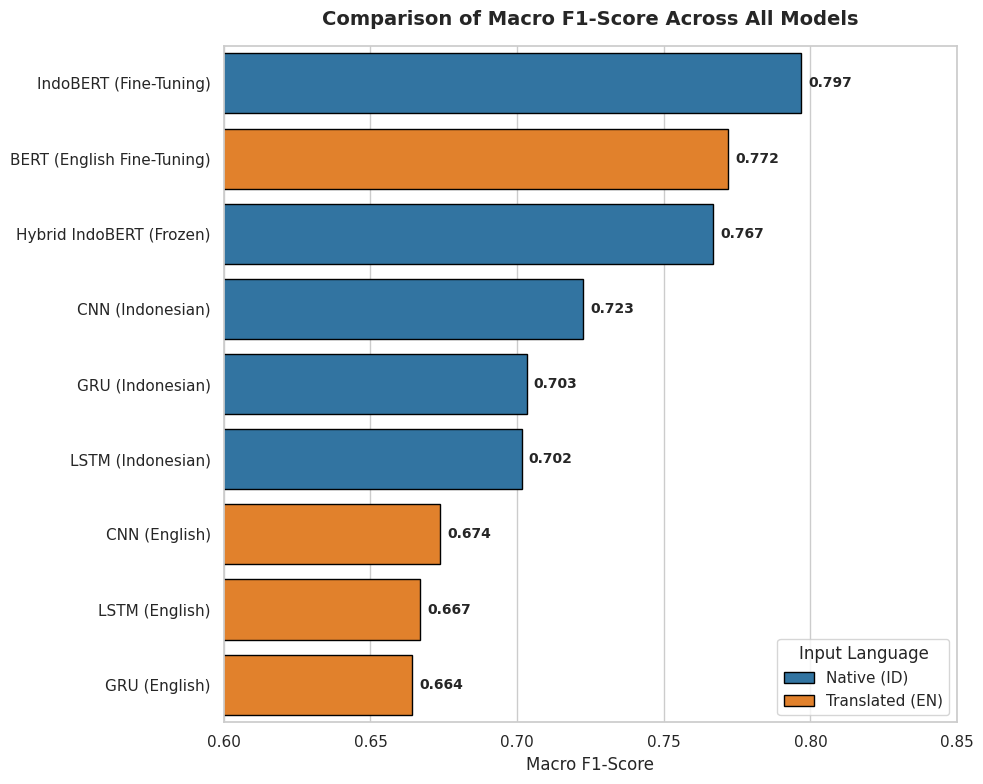

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

# y = Model Strategy (Category), x = Macro F1-Score (Value)
barplot = sns.barplot(
    data=df_final_report,
    y='Model Strategy', # Model name on Y axis (Left)
    x='Macro F1-Score', # Value on X axis (Bottom)
    hue='Input Language',
    palette={'Native (ID)': '#1f77b4', 'Translated (EN)': '#ff7f0e'},
    edgecolor='black',
    orient='h'
)

# Title and Label
plt.title('Comparison of Macro F1-Score Across All Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Macro F1-Score', fontsize=12)
plt.ylabel('')

# Adding the number to the SAMPLING of each bar (not above)
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.3f', padding=5, fontsize=10, fontweight='bold')

plt.xlim(0.6, 0.85)

# Set legend
plt.legend(title='Input Language', loc='lower right', bbox_to_anchor=(1, 0))

plt.tight_layout()

# Save
plt.savefig('f1_score_horizontal.png', dpi=300, bbox_inches='tight')
print("Grafik Horizontal berhasil disimpan!")
plt.show()